In [1]:
!pip install pandas bertopic hdbscan numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ROOT_PATH = "/content/drive/MyDrive/Senior-Project"

In [4]:
ASSETS = ROOT_PATH

import pandas as pd

df_path = f"{ASSETS}/postprocessed_output_with_classified.csv"

df = pd.read_csv(df_path)
df.head(2)

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,scrape_date,source_file,tokens,pred_label,pred_score,prob_malexandersalazar/xlm-roberta-large-binary-cls-toxicity,pred_malexandersalazar/xlm-roberta-large-binary-cls-toxicity
0,1139881968735096832,twitter,post,https://x.com/9veW7NqOtKBYvCi/status/113988196...,text,2019-06-15T13:06:53.000Z,selenium_x_scraper_v1,รับวิจารณ์ควยนะค่ะ ตอบทุกคนค่ะ 1.รีทวิตโพสนี้ก...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['รับ', 'วิจารณ์', 'ควย', 'นะ', 'ค่ะ', 'ตอบ', ...",unsafe,0.873818,0.999991,1.0
1,1146471075519221761,twitter,post,https://x.com/manoww089/status/114647107551922...,text,2019-07-03T17:29:39.000Z,selenium_x_scraper_v1,กดรีทวีต ติดตาม รอกันเลย ค่า,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['กด', 'รี', 'ทวีต', 'ติดตาม', 'รอ', 'กัน', 'เ...",safe,0.941913,0.002729,0.0


In [5]:
import numpy as np

model = "new5558/simcse-model-wangchanberta-base-att-spm-uncased"
ENCODER = model.replace("/","_")
embedded_path = f'{ASSETS}/postprocessed_embeddings/{ENCODER}.npy'

embeddings = np.load(embedded_path)
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (42132, 768)


In [6]:
def passthrough_tokenizer(text):
    return text.split()

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    tokenizer=passthrough_tokenizer,
    token_pattern=None,
    lowercase=False,
    stop_words=None,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
)

In [7]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=35,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# topic_model = BERTopic(
#     language=None,
#     vectorizer_model=vectorizer_model,
#     umap_model=umap_model,
#     hdbscan_model=hdbscan_model,
#     calculate_probabilities=True,
#     verbose=True
# )

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [8]:
import numpy as np

embedded_path = f'{ASSETS}/postprocessed_embeddings/{model.replace("/","_")}.npy'

# 2. Load it back later
loaded_embeddings = np.load(embedded_path)

# # Verify it looks the same
print(loaded_embeddings)

[[ 0.11058958 -0.03223726 -1.7584467  ...  0.07847606 -0.42223322
  -0.9791442 ]
 [ 0.35227278  0.28797308  2.0000193  ...  0.2800569   0.1427126
  -0.17260137]
 [ 0.51662266 -1.8995267  -1.2067847  ... -1.1720523  -0.7771739
  -0.45144835]
 ...
 [-0.83795244  0.98140657 -1.6019189  ... -0.6267883  -1.3713913
  -0.05497512]
 [ 0.833063   -0.3133333   0.07126226 ... -0.01415623 -1.3154367
  -0.93909806]
 [ 0.49209893  1.3230155   0.23094386 ... -0.74571544 -0.3430819
  -0.12054368]]


In [9]:
import os

# 1. Construct the path exactly as you do in the error line
topic_model_path = f"{ASSETS}/bertopic_model/my_bertopic_model_{ENCODER}_cv_1_2_config_u_scan"


In [11]:
from bertopic import BERTopic
# Load locally
topic_model = BERTopic.load(
    topic_model_path,
)

In [12]:
topics = topic_model.topics_
probs = topic_model.probabilities_

In [13]:
df["topic"] = topics

topic_labels = topic_model.get_topic_info().set_index("Topic")["Name"].to_dict()
df["topic_name"] = df["topic"].map(topic_labels)

In [14]:
from umap import UMAP

umap_2d = UMAP(
    n_neighbors=35,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embedding_2d = umap_2d.fit_transform(embeddings)

df_plot = pd.DataFrame({
    "x": embedding_2d[:, 0],
    "y": embedding_2d[:, 1],
    "topic": topics,
    "text": df["text"].tolist()
})

In [15]:
df_plot_cleaned = df_plot[df_plot["topic"] != -1]

In [16]:
topic_info = topic_model.get_topic_info()
topic_name_map = dict(zip(topic_info["Topic"], topic_info["Name"]))

df_plot_cleaned["topic_name"] = df_plot_cleaned["topic"].map(topic_name_map)

In [17]:
gender_identity = [
    1, 7, 17, 18, 21, 26, 27, 31, 32,
    40, 42, 72, 75, 105, 108, 125, 137,
    145, 149, 158
]

gender_group = gender_identity
df_gender = df_plot_cleaned[df_plot_cleaned["topic"].isin(gender_group)]

centroids = df_gender.groupby("topic")[["x", "y"]].mean()

In [18]:
!wget -q https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Regular.ttf
!wget -q https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Bold.ttf

import matplotlib.font_manager as fm
kanit_font = fm.FontProperties(fname="Kanit-Regular.ttf")
kanit_font_bold = fm.FontProperties(fname="Kanit-Bold.ttf")

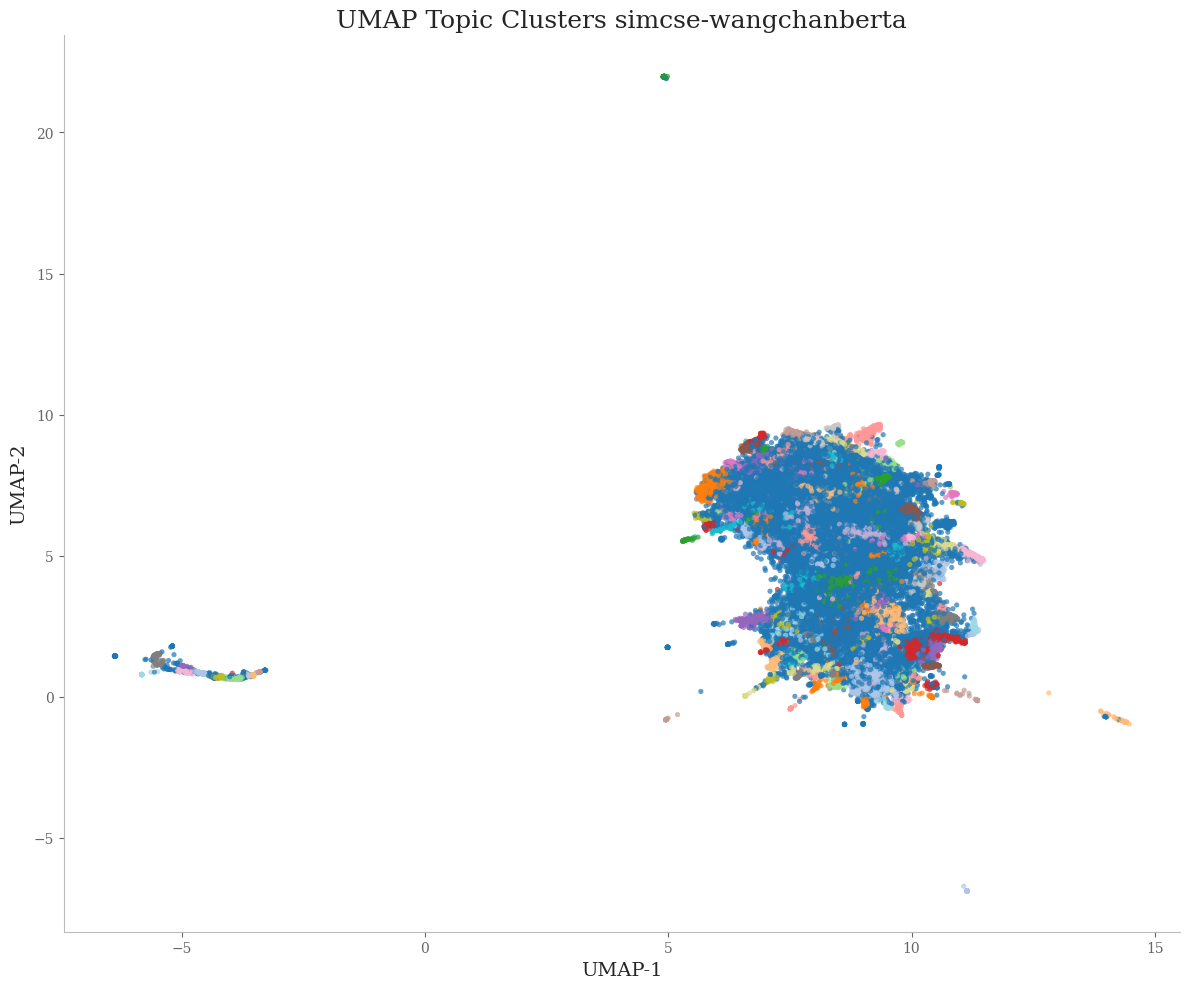

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# Global Styling (Your Style)
# ---------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]  # safest
plt.rcParams["axes.edgecolor"] = "#BBBBBB"
plt.rcParams["axes.labelcolor"] = "#252525"
plt.rcParams["xtick.color"] = "#666666"
plt.rcParams["ytick.color"] = "#666666"
plt.rcParams["text.color"] = "#252525"

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df_plot,
    x="x",
    y="y",
    hue="topic",
    palette="tab20",     # functional, not aesthetic
    s=14,                # small points for dense clusters
    alpha=0.7,
    linewidth=0,
    legend=False         # ❗ important for 100+ topics
)

plt.title(f"UMAP Topic Clusters simcse-wangchanberta", fontsize=18)
plt.xlabel("UMAP-1", fontsize=14)
plt.ylabel("UMAP-2", fontsize=14)

# Minimalist axes
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.tight_layout()
plt.show()

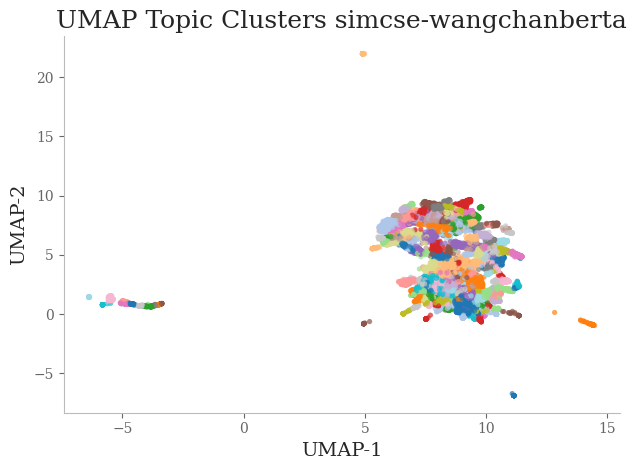

In [ ]:

plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df_plot_cleaned,
    x="x",
    y="y",
    hue="topic",
    palette="tab20",     # functional, not aesthetic
    s=14,                # small points for dense clusters
    alpha=0.7,
    linewidth=0,
    legend=False         # ❗ important for 100+ topics
)

plt.title(f"UMAP Topic Clusters simcse-wangchanberta", fontsize=18)
plt.xlabel("UMAP-1", fontsize=14)
plt.ylabel("UMAP-2", fontsize=14)

# Minimalist axes
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.tight_layout()
plt.show()

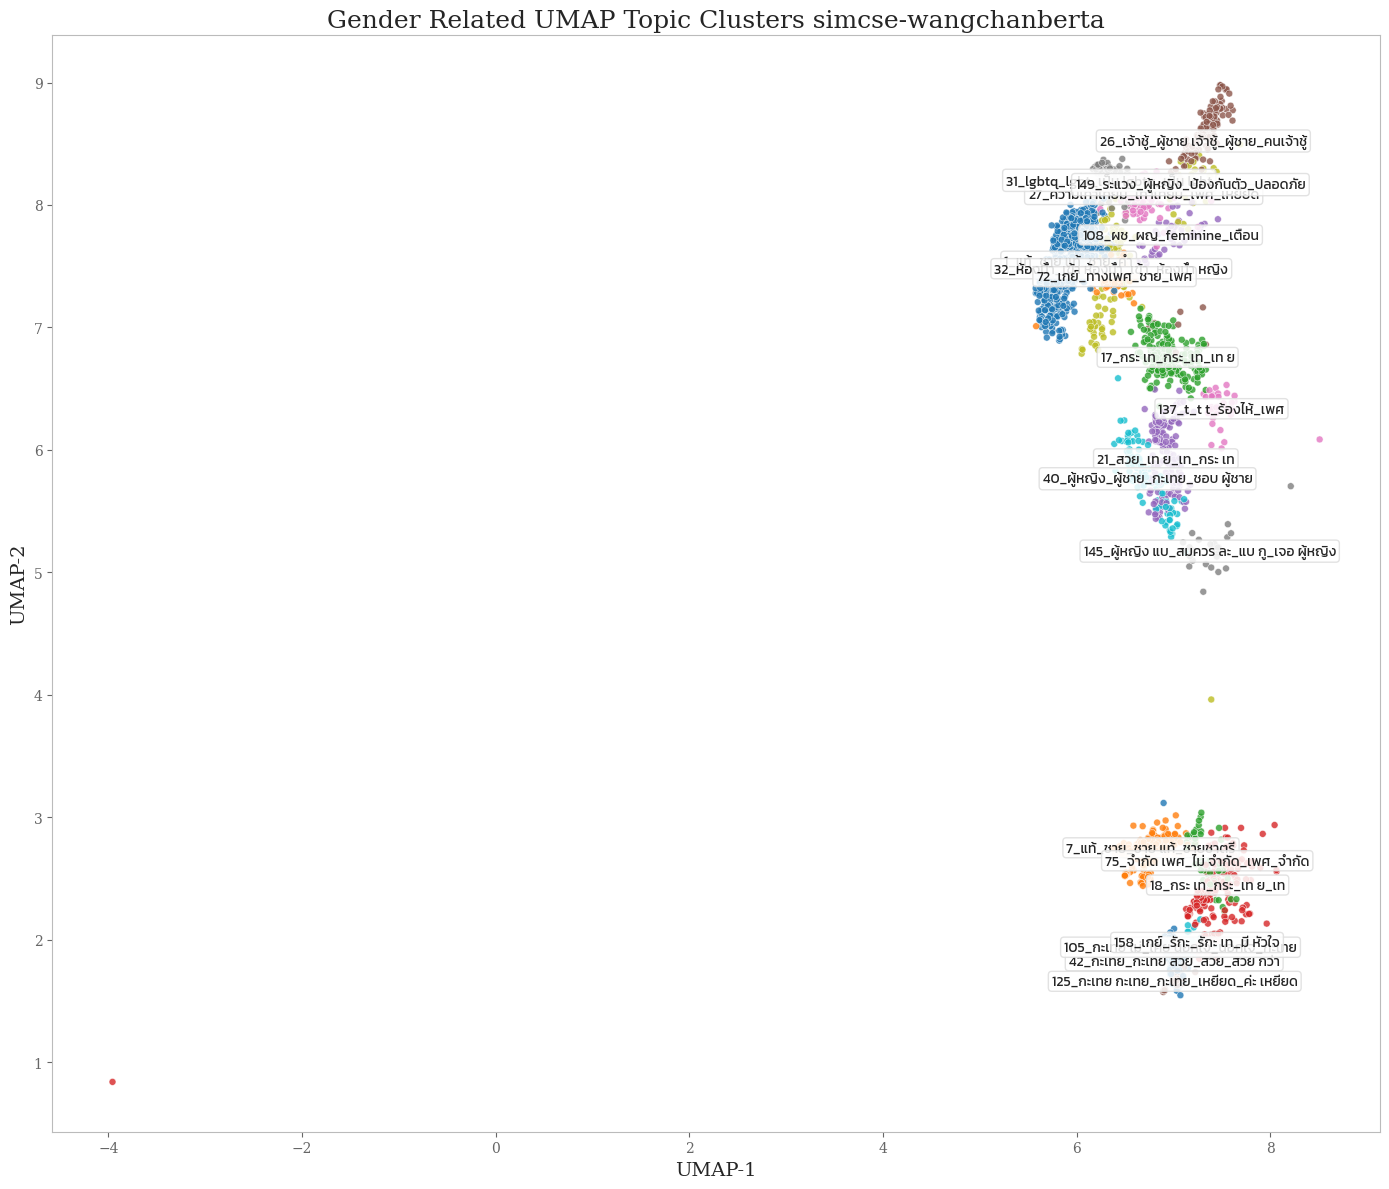

In [54]:
# import matplotlib.pyplot as plt
# import seaborn as sns

plt.figure(figsize=(14, 12))
sns.scatterplot(
    data=df_gender,
    x="x", y="y",
    hue="topic",
    palette="tab10",
    s=25,
    alpha=0.8,
    legend=False
)

for topic_id, row in centroids.iterrows():
    name = topic_name_map.get(topic_id, f"Topic {topic_id}")
    plt.text(
        row["x"], row["y"],
        name,
        fontsize=10,
        ha="center",
        va="center",
        fontproperties=kanit_font,
        bbox=dict(facecolor="white", edgecolor="#DDDDDD", alpha=0.85, boxstyle="round,pad=0.25")
    )

plt.title(f"Gender Related UMAP Topic Clusters simcse-wangchanberta", fontsize=18)
plt.xlabel("UMAP-1", fontsize=14)
plt.ylabel("UMAP-2", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_topic_clusters(interest_set, topic_name_refined):
  df = df_plot_cleaned[df_plot_cleaned["topic"].isin(interest_set)]
  centroids = df.groupby("topic")[["x", "y"]].mean()

  plt.figure(figsize=(14, 12))
  sns.scatterplot(
      data=df,
      x="x", y="y",
      hue="topic",
      palette="tab10",
      s=25,
      alpha=0.8,
      legend=False
  )

  for topic_id, row in centroids.iterrows():
      name = topic_name_map.get(topic_id, f"Topic {topic_id}")
      plt.text(
          row["x"], row["y"],
          name,
          fontsize=10,
          ha="center",
          va="center",
          fontproperties=kanit_font,
          bbox=dict(facecolor="white", edgecolor="#DDDDDD", alpha=0.85, boxstyle="round,pad=0.25")
      )

  plt.title(f"{topic_name_refined} Topic Cluster Visualization", fontsize=18)
  plt.xlabel("UMAP-1", fontsize=14)
  plt.ylabel("UMAP-2", fontsize=14)
  plt.tight_layout()
  plt.show()

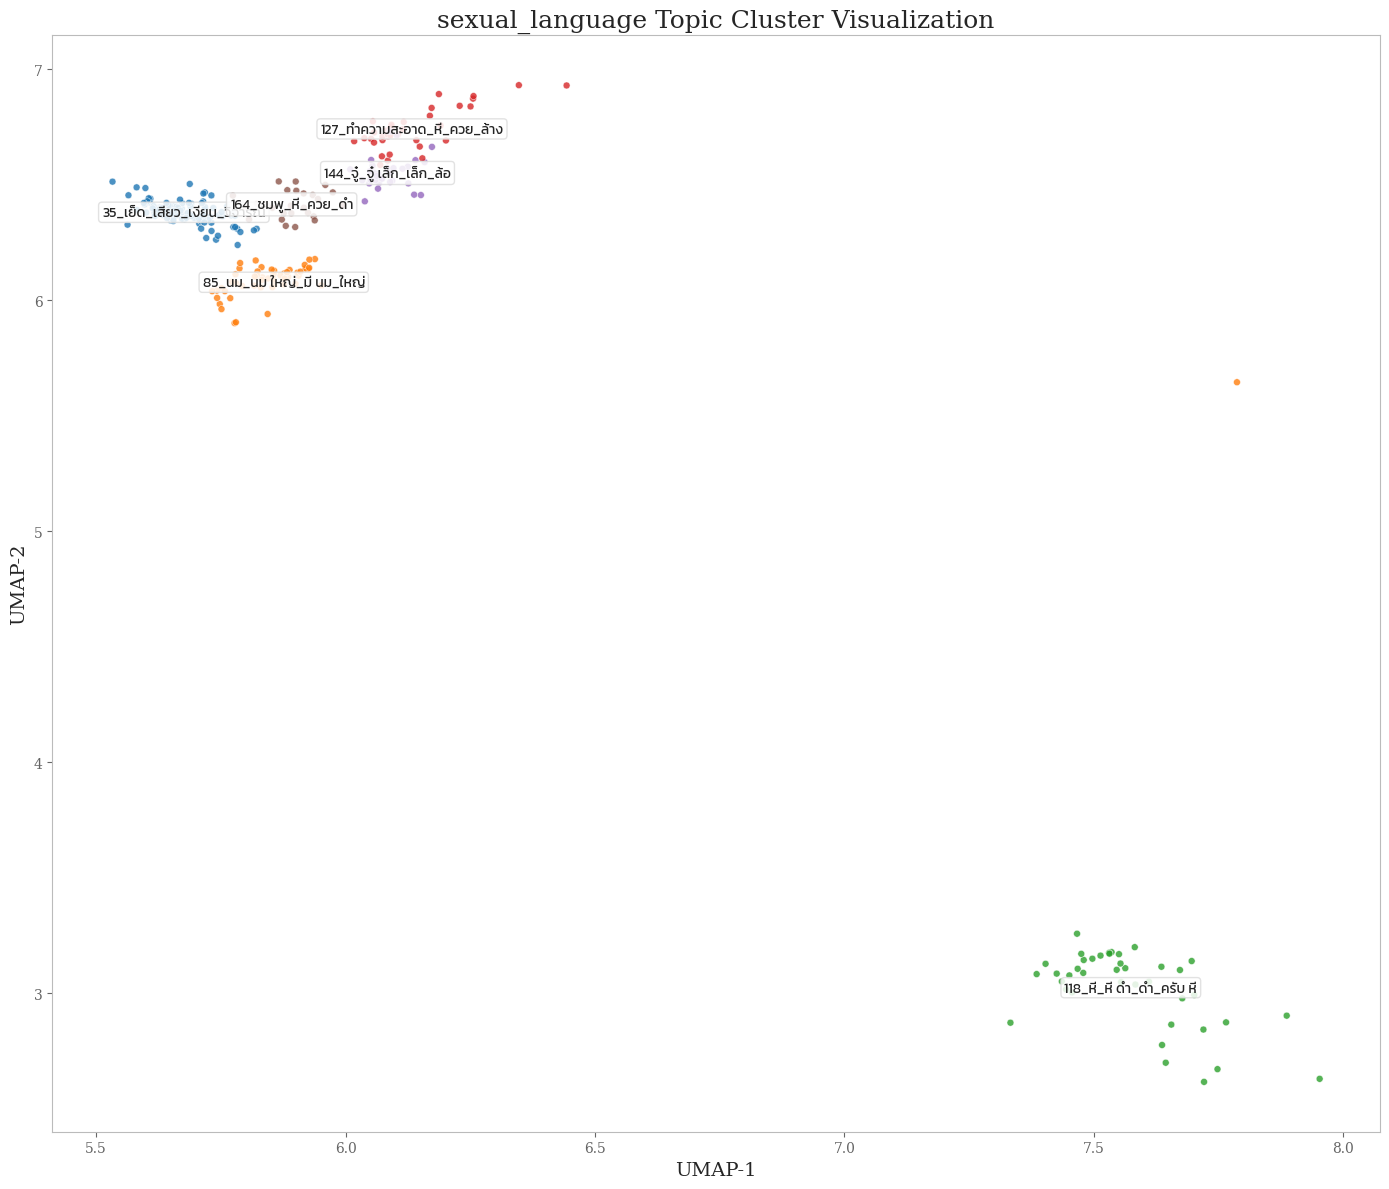

In [38]:
sexual_language = [
    35, 85, 118, 127, 144, 164
]
topic_name_refined = "sexual_language"
interest_set = sexual_language
plot_topic_clusters(interest_set, topic_name_refined)

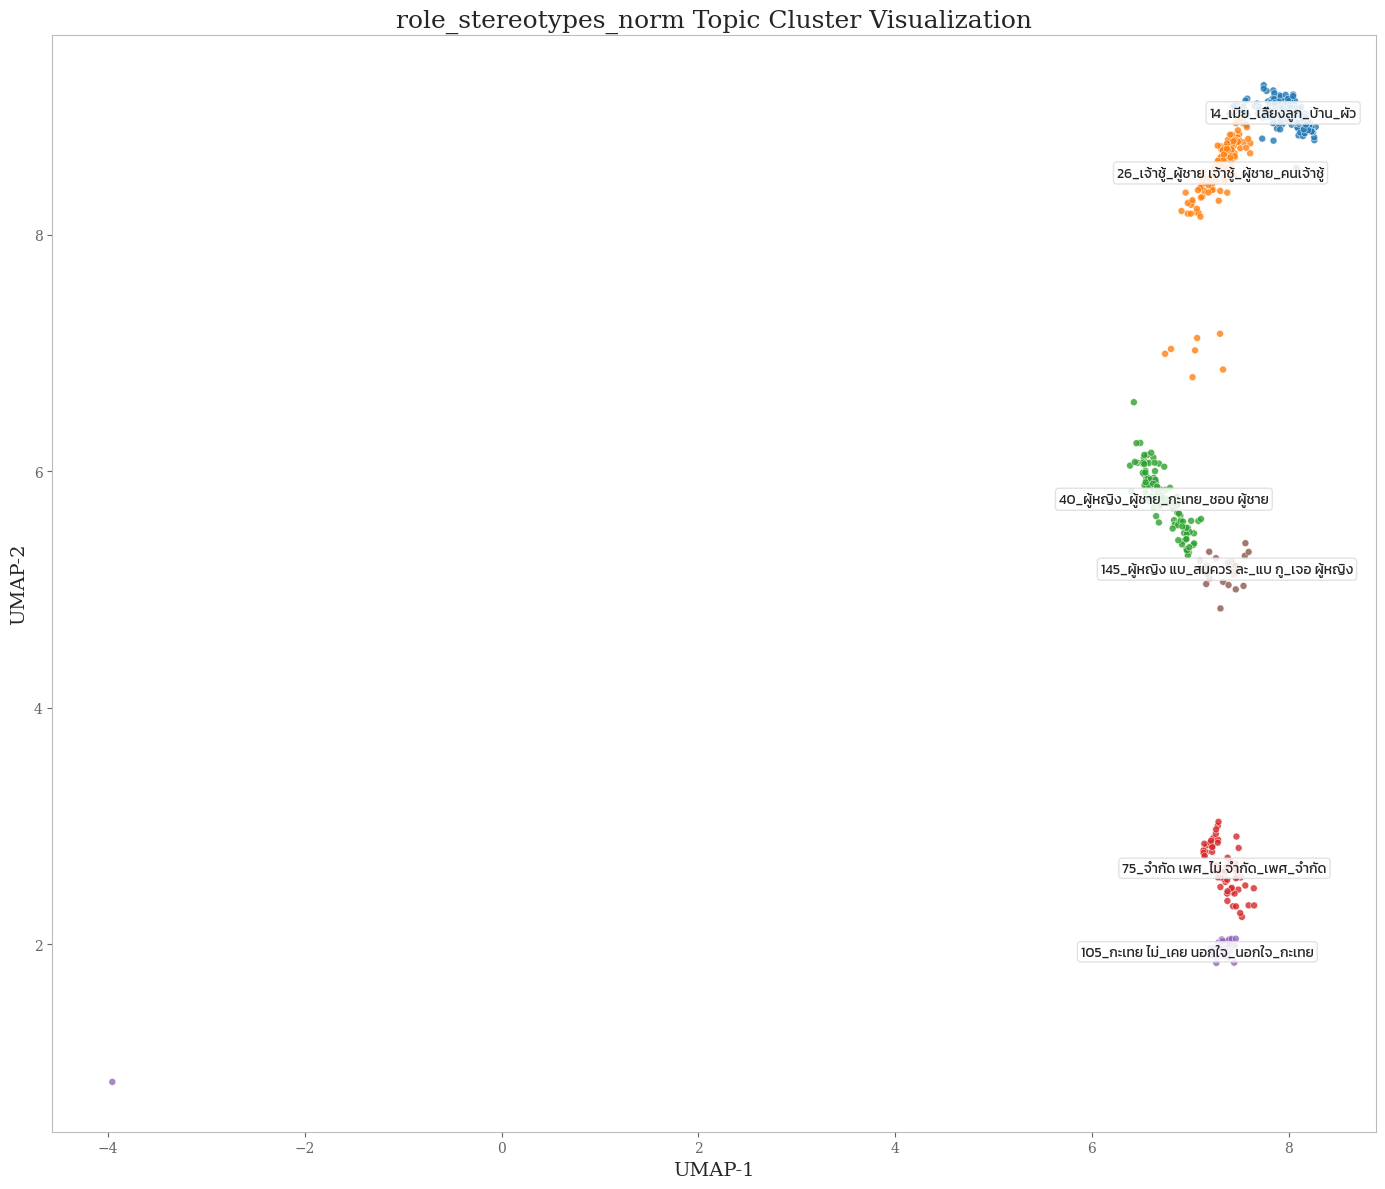

In [39]:
role_stereotypes_norm = [
    14, 26, 40, 75, 105, 145
]
topic_name_refined = "role_stereotypes_norm"
interest_set = role_stereotypes_norm
plot_topic_clusters(interest_set, topic_name_refined)

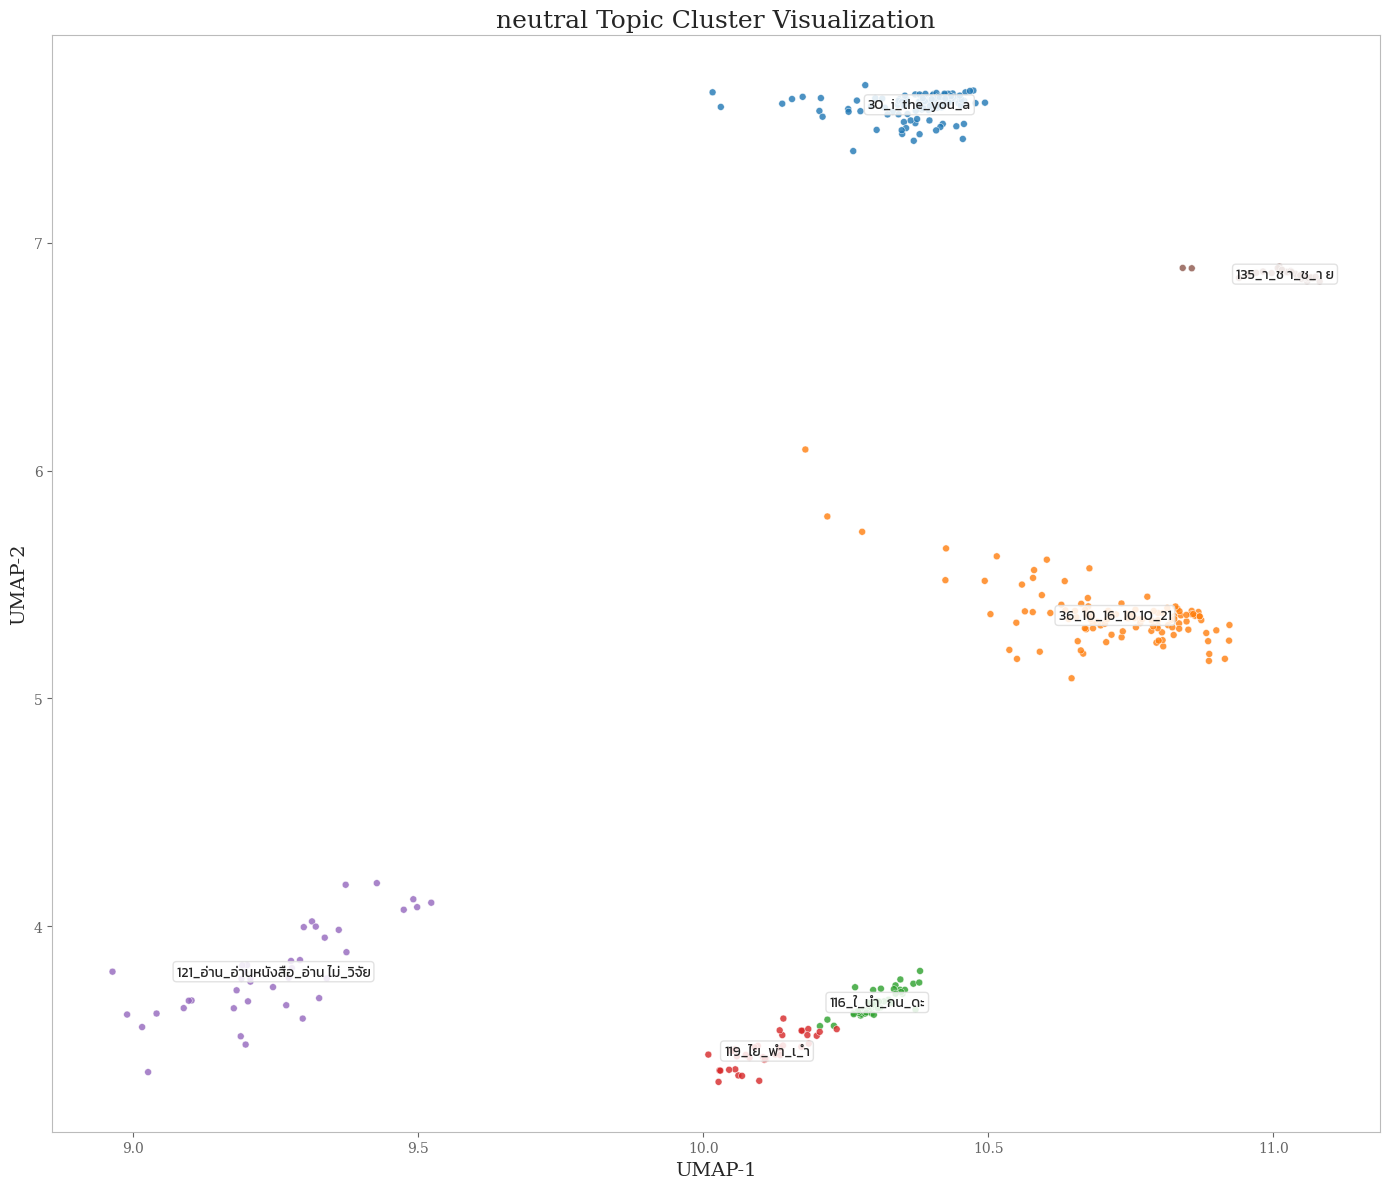

In [40]:
neutral = [-1, 30, 36, 116, 119, 121, 135]
topic_name_refined = "neutral"
interest_set = neutral
plot_topic_clusters(interest_set, topic_name_refined)

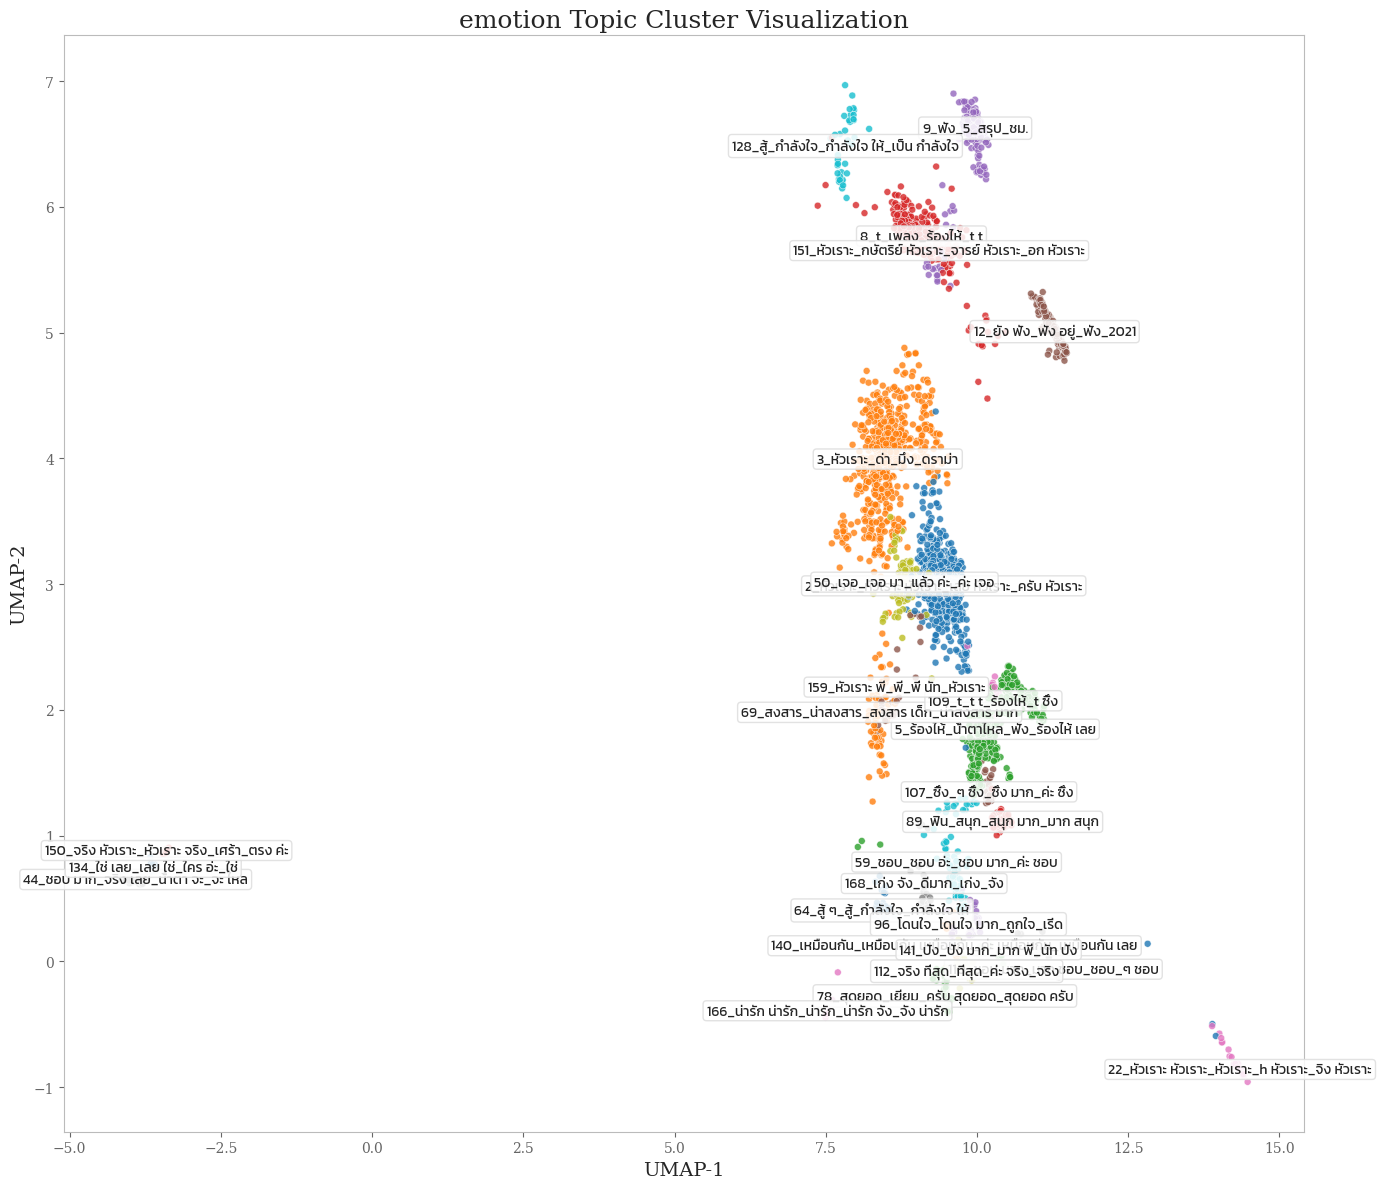

In [41]:
emotion = [
    2, 3, 5, 8, 9, 12, 22, 44, 50, 59,
    64, 69, 78, 89, 96, 107, 109, 110,
    112, 128, 134, 140, 141, 150, 151,
    159, 166, 168
]
topic_name_refined = "emotion"
interest_set = emotion
plot_topic_clusters(interest_set, topic_name_refined)

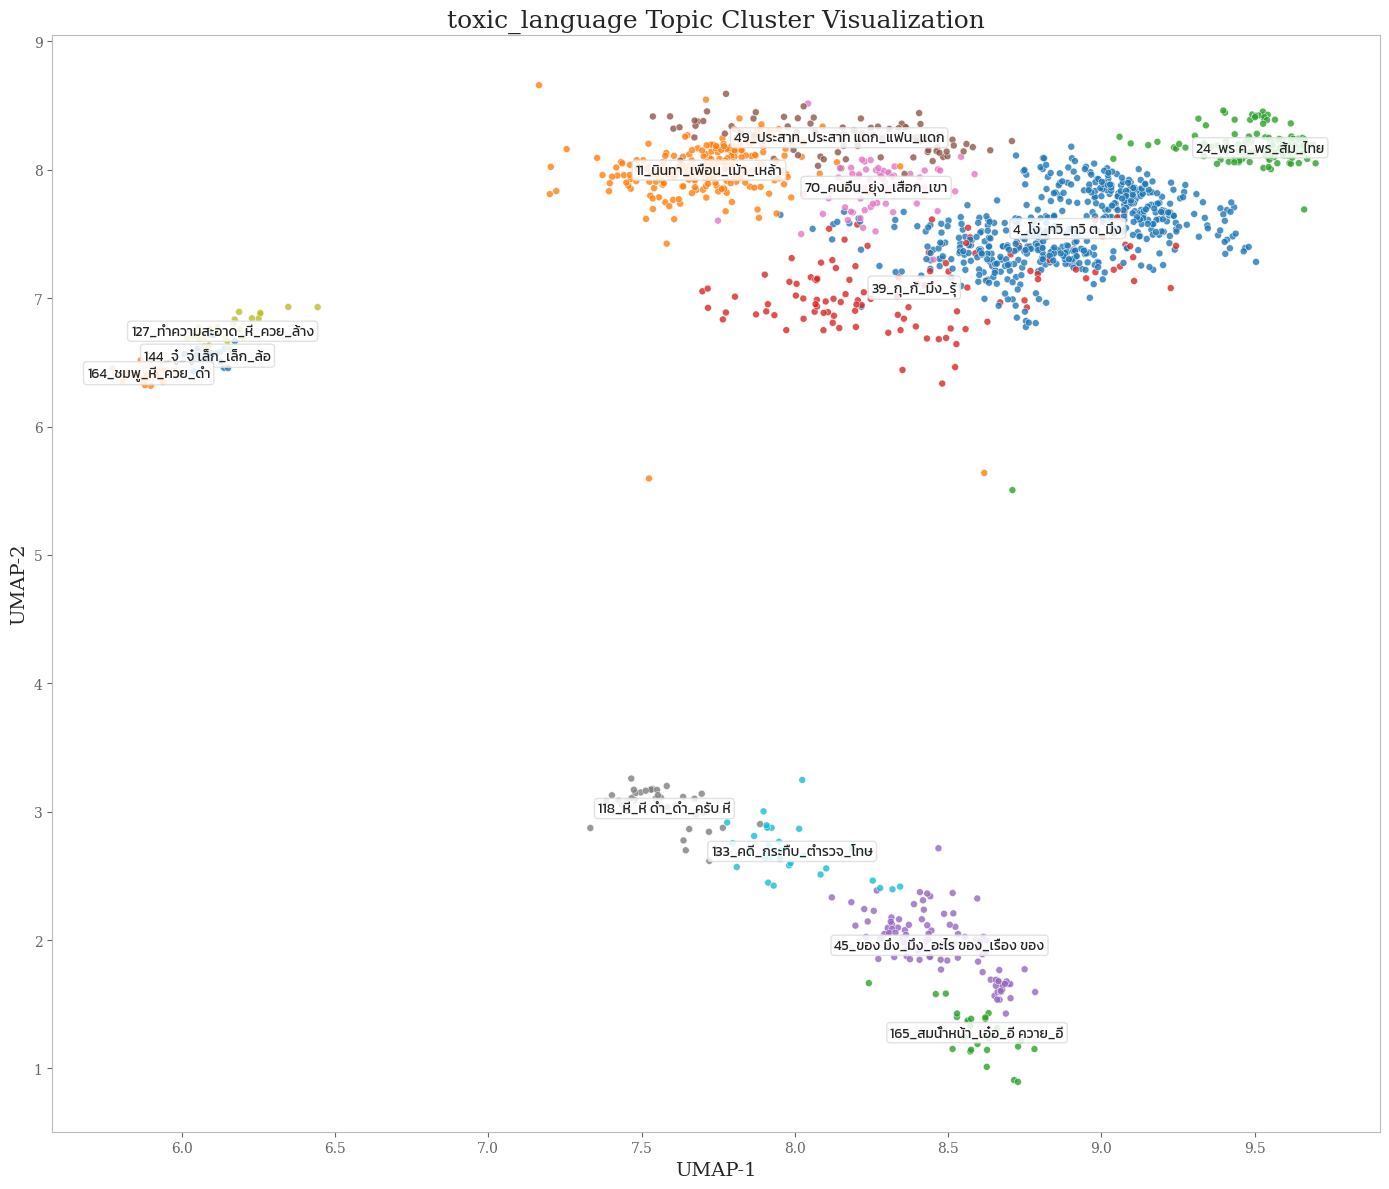

In [44]:
toxic_language = [
    4, 11, 24, 39, 45, 49, 70,
    118, 127, 133, 144, 164, 165,
    # 80,
]
topic_name_refined = "toxic_language"
interest_set = toxic_language
plot_topic_clusters(interest_set, topic_name_refined)

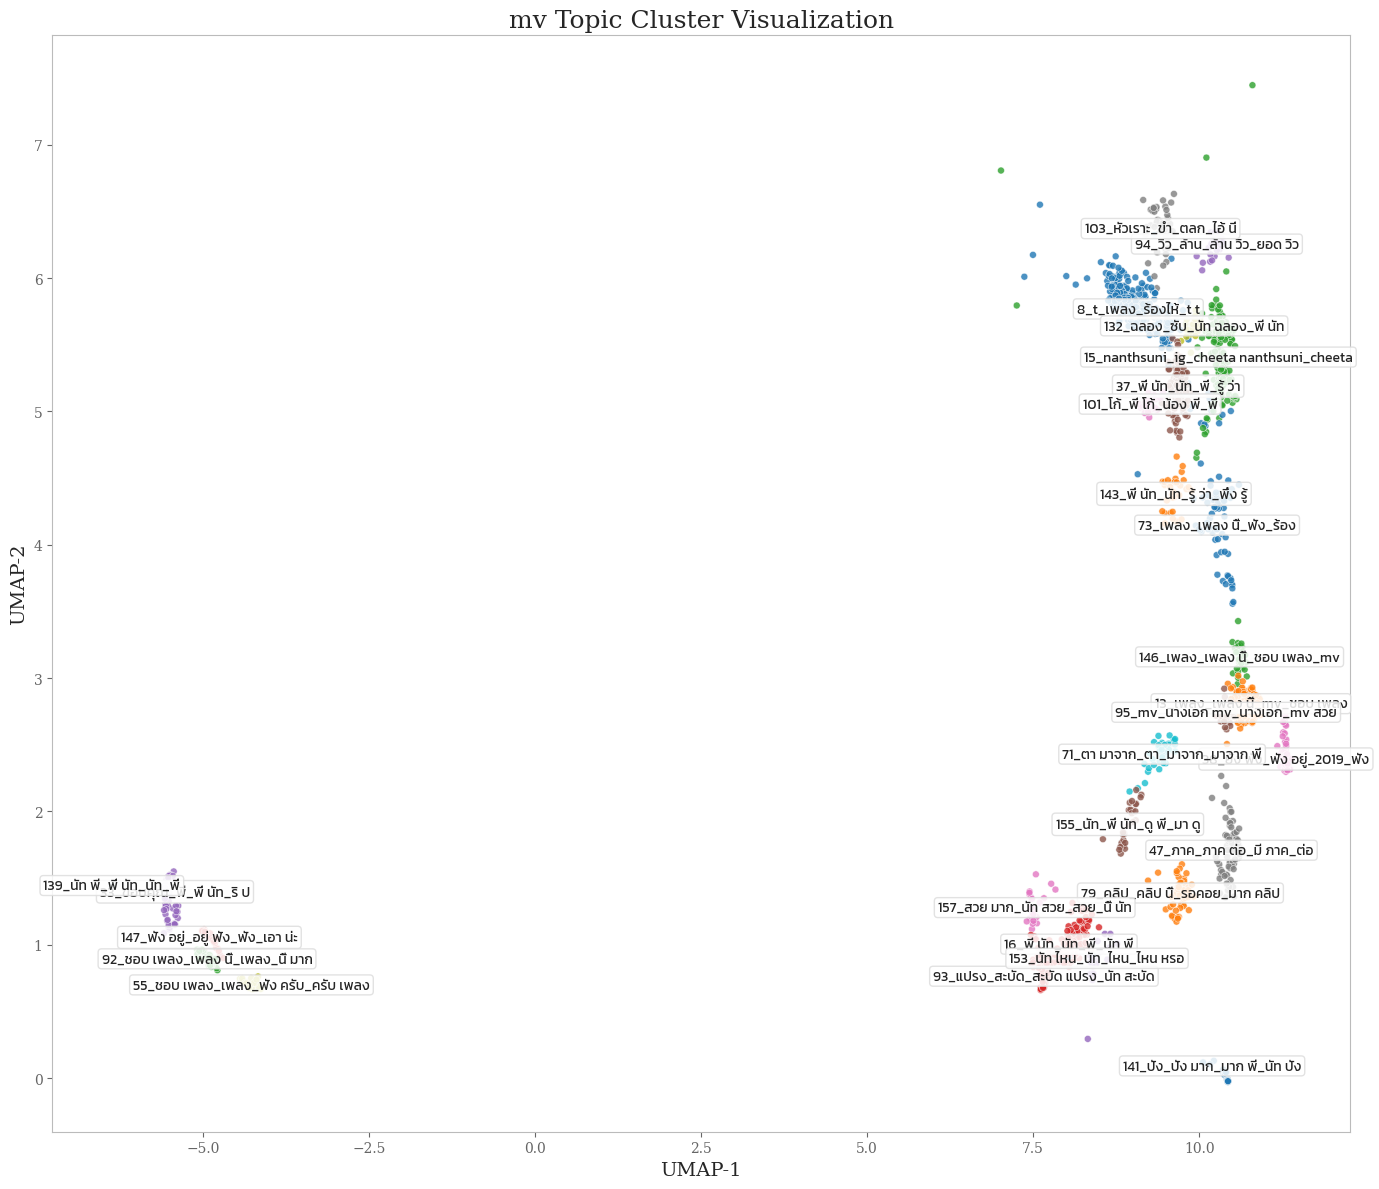

In [46]:
mv = [
    8, 13, 15, 16, 33, 37, 38, 47,
    55, 71, 73, 79, 92, 93, 94, 95,
    101, 103, 132, 139, 141, 143,
    146, 147, 153, 155, 157
]
topic_name_refined = "mv"
interest_set = mv
plot_topic_clusters(interest_set, topic_name_refined)

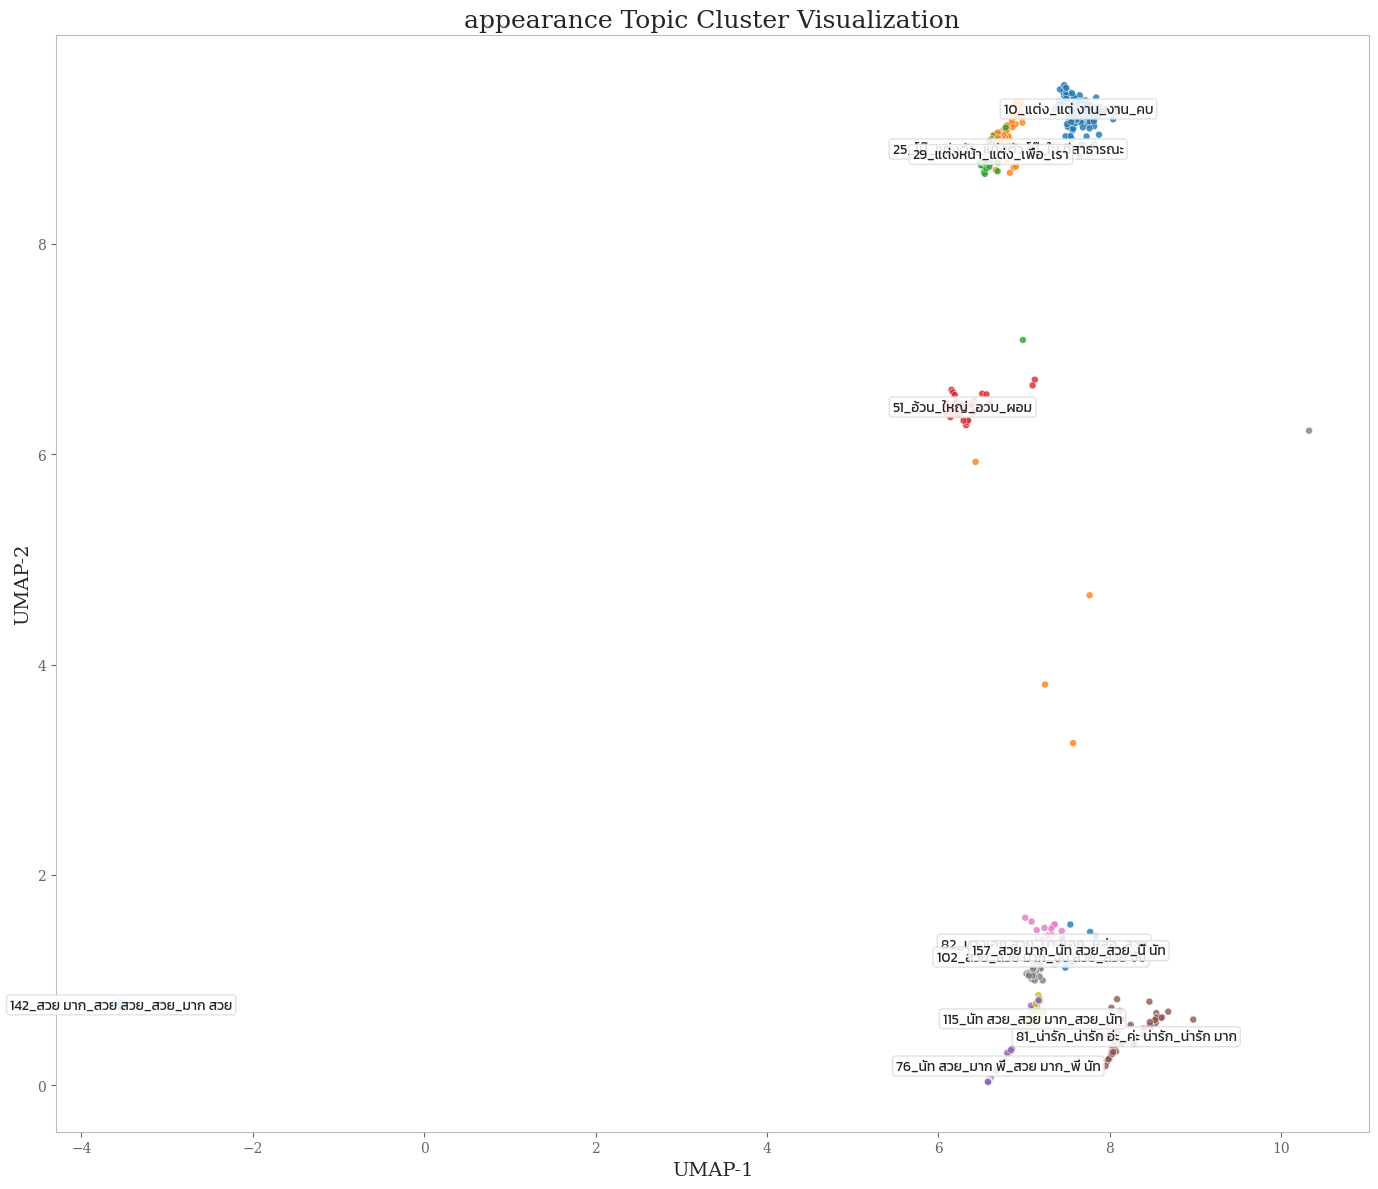

In [47]:
appearance = [
    10, 25, 29, 51, 76, 81, 82,
    102, 115, 142, 157
]
topic_name_refined = "appearance"
interest_set = appearance
plot_topic_clusters(interest_set, topic_name_refined)

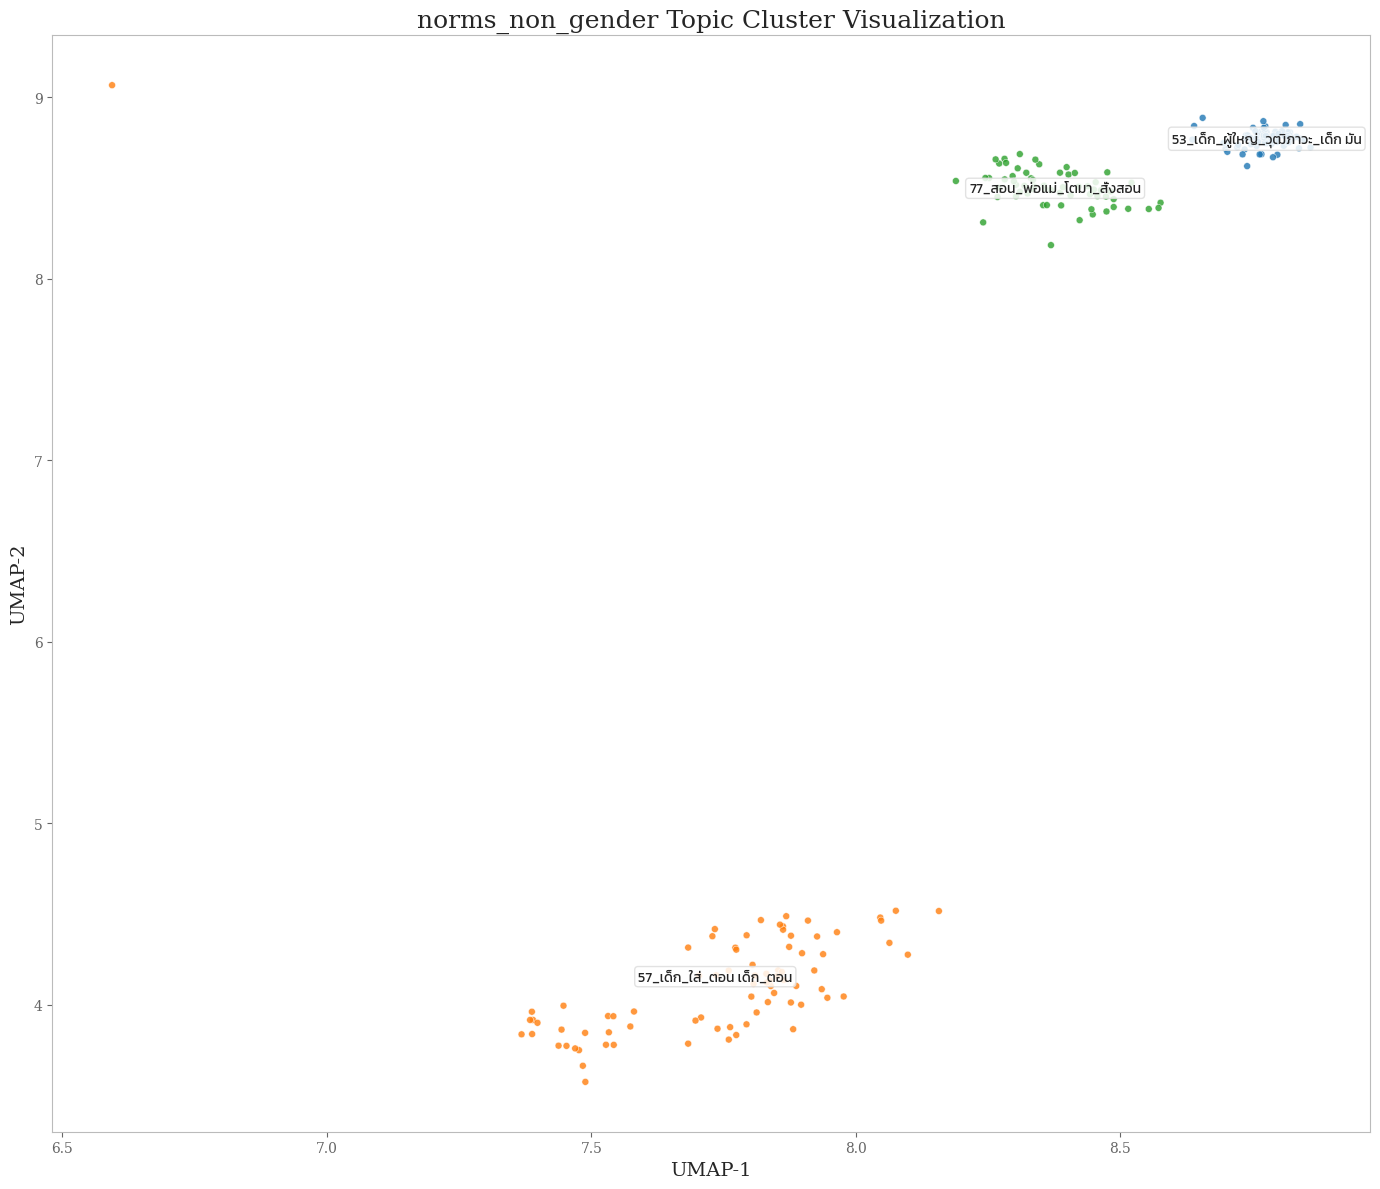

In [50]:
norms_non_gender = [
    # 14,
    53, 57, 77,
    # 91
]
topic_name_refined = "norms_non_gender"
interest_set = norms_non_gender
plot_topic_clusters(interest_set, topic_name_refined)

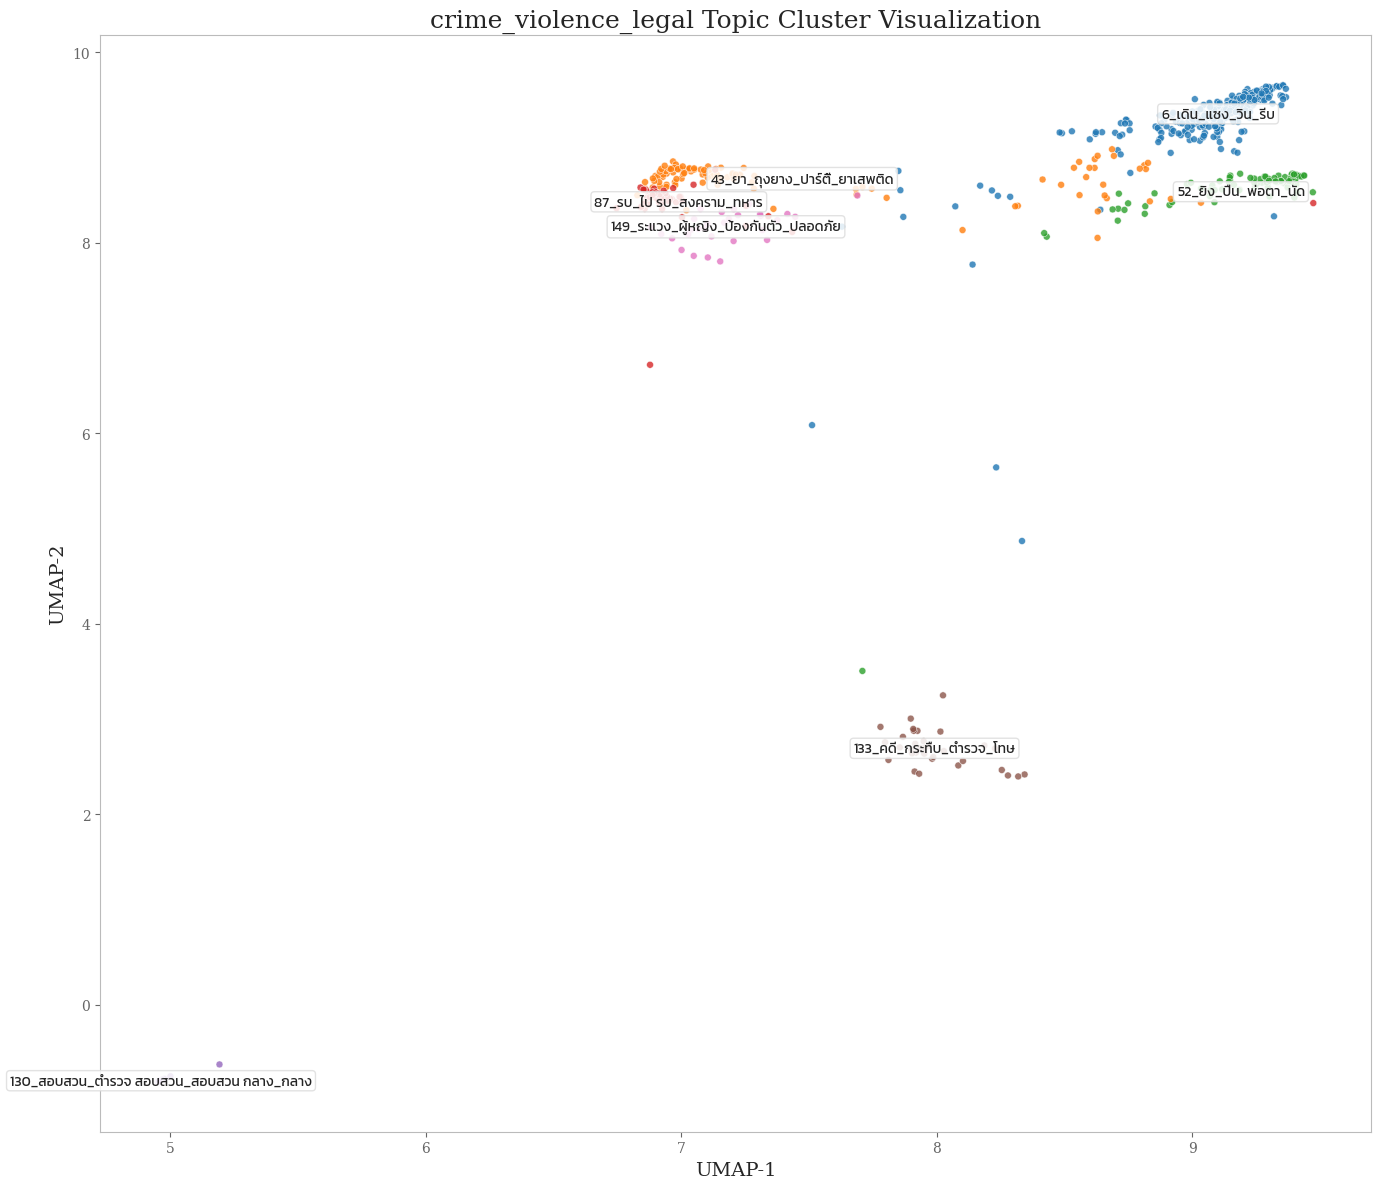

In [52]:
crime_violence_legal = [
    6,   # walking, danger, fear traffic
    43,  # drugs, condoms, illegal
    52,  # guns, shooting
    87,  # war / soldiers
    130, # police investigation
    133, # assault / violence
    149  # women’s safety / fear
]
topic_name_refined = "crime_violence_legal"
interest_set = crime_violence_legal
plot_topic_clusters(interest_set, topic_name_refined)

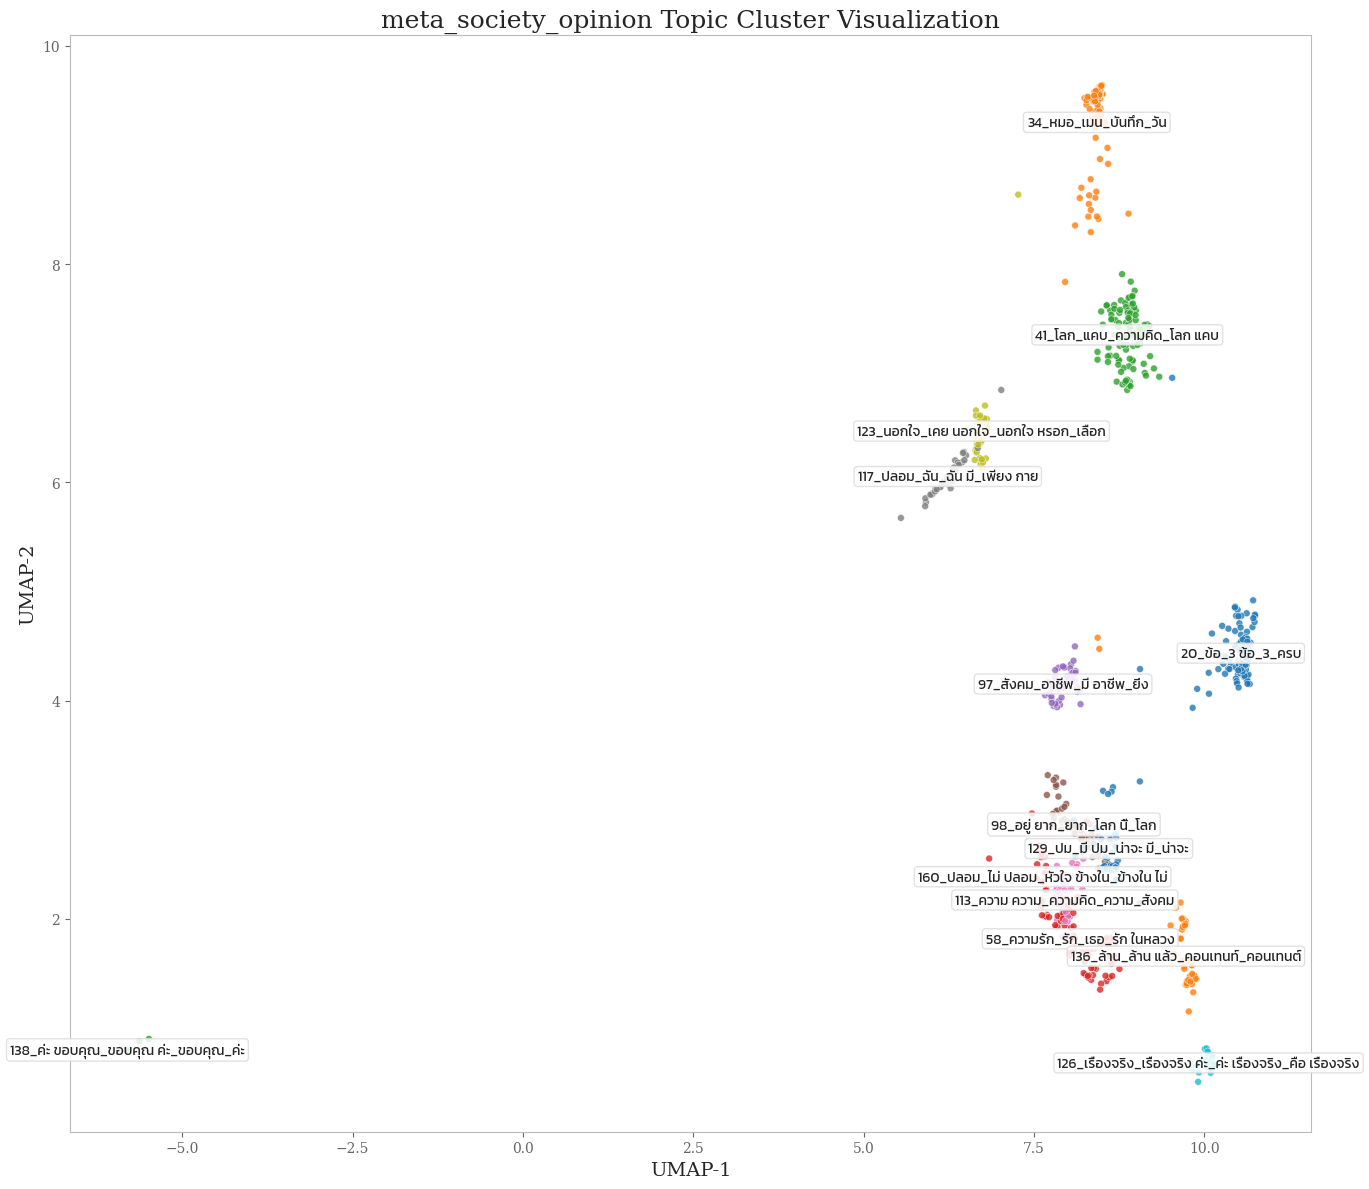

In [53]:
meta_society_opinion = [
    20, 34, 41, 58, 97, 98,
    113, 117, 123, 126, 129,
    136, 138, 160
]
topic_name_refined = "meta_society_opinion"
interest_set = meta_society_opinion
plot_topic_clusters(interest_set, topic_name_refined)

In [ ]:
technology_tools = [30, 48, 74, 111]
food = [162]
commercial_marketing = [136]
clothing_style = [148, 161]
locations = [124]
misc_reactions = [60, 61, 84, 86, 100, 140]